In [136]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [137]:
df = pd.read_csv("https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv")

In [138]:
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [139]:
df

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0
...,...,...,...,...,...,...,...,...,...,...,...
9995,2005,USA,Gasoline,All-wheel drive,4,2470,6,271.0,4690,18.9,27.4
9996,1993,Asia,Gasoline,All-wheel drive,2,2300,6,244.0,4370,19.0,30.0
9997,2014,USA,Gasoline,All-wheel drive,3,2480,6,267.0,4590,18.4,28.1
9998,2004,USA,Hybrid,Rear-wheel drive,5,2180,6,270.0,4450,20.9,32.2


In [140]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [141]:
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [142]:
cols = [
    'engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year',
    'fuel_efficiency_mpg'
]

df = df[cols]

In [143]:
df

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0
...,...,...,...,...,...
9995,2470,271.0,4690,2005,27.4
9996,2300,244.0,4370,1993,30.0
9997,2480,267.0,4590,2014,28.1
9998,2180,270.0,4450,2004,32.2


<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

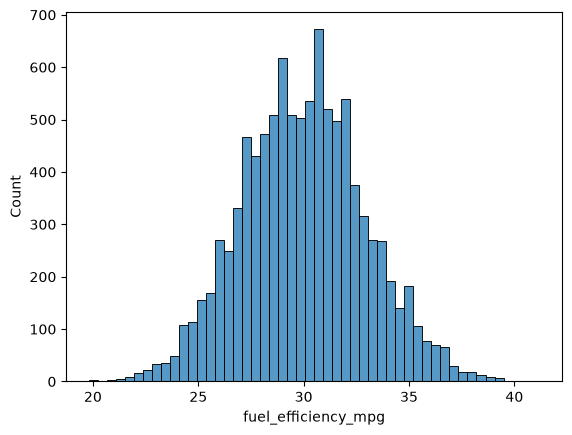

In [144]:
#There isn't a long tail in distribution of  fuel_efficiency_mpg!


sns.histplot(df.fuel_efficiency_mpg, bins=50)

In [145]:
#Q1


missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values)

Missing values per column:
engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64


In [146]:
#Q2

median_horsepower = df['horsepower'].median()

print(f"Median horsepower: {median_horsepower}")

Median horsepower: 254.0


In [147]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [148]:
#option 1

df_train

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
6252,1900,239.0,3790,2015,32.5
4684,2000,224.0,4380,1992,29.1
1731,2330,286.0,4090,2022,34.1
4742,2300,NaN,4150,1997,30.6
4521,2340,269.0,4400,2001,30.7
...,...,...,...,...,...
7895,2280,242.0,4590,2018,29.8
9590,2300,NaN,4240,1984,25.1
7288,2240,255.0,4190,1989,27.7
278,2430,254.0,4280,2020,31.6


In [149]:
y_train = df_train.fuel_efficiency_mpg.values 
y_val = df_val.fuel_efficiency_mpg.values 
y_test = df_test.fuel_efficiency_mpg.values 

In [150]:
features = ['engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year',]

In [151]:
X_train =df_train[features]
X_val = df_val[features]

In [152]:
X_train = X_train.fillna(0)
X_val = X_val.fillna(0)

In [153]:
X_train.isnull().sum()

engine_displacement    0
horsepower             0
vehicle_weight         0
model_year             0
dtype: int64

In [154]:
X_val = X_val.values 
X_train = X_train.values

In [155]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [156]:
w0, w = train_linear_regression(X_train, y_train)

y_pred = w0 + X_val.dot(w)

In [157]:
w ,w0

(array([-1.51505520e-03, -4.74024794e-06, -3.95418397e-03,  1.02146785e-01]),
 np.float64(-153.88496188223104))

In [158]:
y_pred 

array([31.64502134, 29.86572978, 31.58838899, ..., 30.53133298,
       30.75085098, 31.62912778], shape=(2000,))

In [159]:
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)


In [161]:
score = rmse(y_val, y_pred)
score

np.float64(2.205293194751098)

In [162]:
round(score,3)

np.float64(2.205)

In [163]:
#option 2

mean_horsepower = df_train.horsepower.mean()
mean_horsepower

np.float64(254.46338337605272)

In [164]:
X_train_mean = df_train[features].fillna(mean_horsepower).values
X_val_mean = df_val[features].fillna(mean_horsepower).values

In [165]:
w0, w = train_linear_regression(X_train_mean, y_train)

In [166]:
y_pred_mean = w0 + X_val_mean.dot(w)

In [167]:
score = rmse(y_val, y_pred_mean)
round(score, 3)


np.float64(2.202)

In [168]:


def train_linear_regression_reg(X, y, r):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]



In [169]:


for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0, w = train_linear_regression_reg(X_train, y_train, r)
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred)
    print(r, round(score, 4))



0 2.2053
0.01 2.2058
0.1 2.2241
1 2.3492
5 2.4094
10 2.4195
100 2.4292


In [170]:
scores = list()

for s in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    np.random.seed(s)

    idx = np.arange(n)
    np.random.shuffle(idx)
    
    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]

    y_train = df_train.fuel_efficiency_mpg.values
    y_val = df_val.fuel_efficiency_mpg.values

    X_train = df_train[features].fillna(0).values
    X_val = df_val[features].fillna(0).values

    w0, w = train_linear_regression(X_train, y_train)

    y_pred = w0 + X_val.dot(w)
    
    score = rmse(y_val, y_pred)
    scores.append(score)

print(scores)
print(np.std(scores))
print(round(np.std(scores), 3))

[np.float64(2.2392041430461465), np.float64(2.2021128210838907), np.float64(2.163419778753095), np.float64(2.2043588768539144), np.float64(2.2018800943312926), np.float64(2.2457851509084974), np.float64(2.269721207952404), np.float64(2.190794599933433), np.float64(2.2166112016864443), np.float64(2.207036592817851)]
0.028781274078187116
0.029


In [171]:
np.random.seed(9)

idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [172]:
df_train_full = pd.concat([df_train, df_val]).reset_index(drop=True)

In [173]:
df_train_full

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2320,246.0,4100,2014,32.5
1,2230,252.0,4250,1998,33.2
2,2700,276.0,4490,2008,32.4
3,2220,269.0,4060,2004,29.9
4,2370,NaN,4690,1979,26.4
...,...,...,...,...,...
7995,2690,324.0,4510,2023,35.7
7996,1920,190.0,4000,1998,30.8
7997,1800,225.0,3980,1994,29.1
7998,1970,232.0,3560,2009,32.2


In [174]:
X_train_full = df_train_full[features].fillna(0).values
y_train_full = df_train_full.fuel_efficiency_mpg.values

In [175]:
X_train

array([[2320.,  246., 4100., 2014.],
       [2230.,  252., 4250., 1998.],
       [2700.,  276., 4490., 2008.],
       ...,
       [2180.,  223., 4360., 2014.],
       [2420.,  248., 4080., 1977.],
       [2040.,  245., 4420., 2018.]], shape=(6000, 4))

In [176]:
y_train

array([32.5, 33.2, 32.4, ..., 34.1, 27.1, 30.7], shape=(6000,))

In [177]:
X_test = df_test[features].fillna(0).values

In [183]:
w0, w = train_linear_regression_reg(X_train_full, y_train_full, 0.001)
pred = w0 + X_test.dot(w)
y_test = df_test.fuel_efficiency_mpg.values


In [182]:
score = rmse(y_test, pred)
round(score, 3)

np.float64(2.236)